# Healthcare NLP Pipeline — Proof of Results
**Cambrian College — AI Program**

This notebook reproduces and proves all metrics reported during training.

| Task | Model | Primary Metric |
|------|-------|----------------|
| Task 1 — Sentiment Classification | LinearSVC (TF-IDF) | F1 Macro = 0.8608 |
| Task 2 — Theme Classification | Logistic Regression Multinomial (TF-IDF) | F1 Macro = 0.9071 |
| Task 3 — NMF Topic Modeling | NMF (TF-IDF) | Reconstruction Error = 226.02 |

**Pipeline:** Raw text → TF-IDF → Linear models (LR, SVM, NMF)

## 0. Setup & Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print('All imports OK')
print(f'Working directory: {os.getcwd()}')

All imports OK
Working directory: c:\Users\danyt\Documents\Projects\healthcare-nlp\notebooks


## 1. Load & Inspect Dataset

In [2]:
DATA_PATH = '../data/patient_feedback.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape     : {df.shape}')
print(f'Columns   : {df.columns.tolist()}')
print(f'Null values:\n{df.isnull().sum()}')
df.head(3)

Shape     : (66657, 4)
Columns   : ['Feedback', 'Sentiment', 'Theme', 'Satisfaction']
Null values:
Feedback        0
Sentiment       0
Theme           0
Satisfaction    0
dtype: int64


,Feedback,Sentiment,Theme,Satisfaction
0,"""I used to take another oral contraceptive, wh...",0,Birth Control,2.5
1,"""This is my first time using any form of birth...",1,Birth Control,4.0
2,"""I had been on the pill for many years. When m...",1,Birth Control,4.0


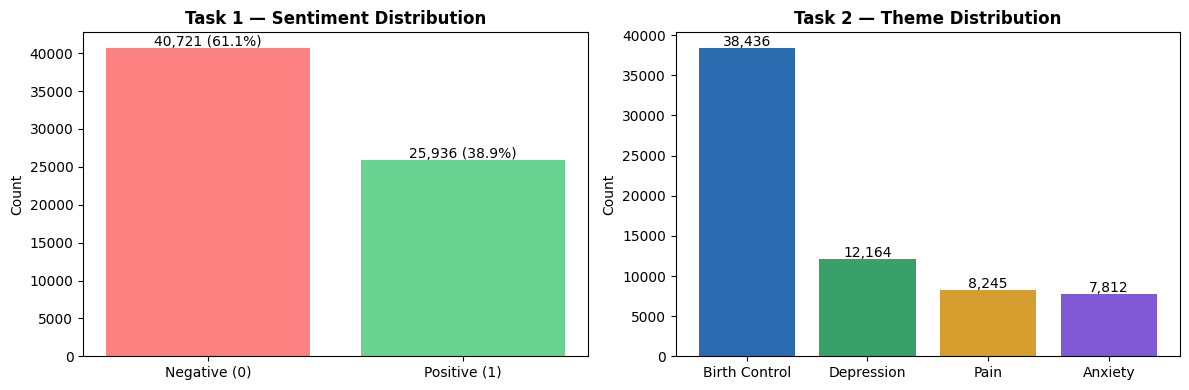

Total rows: 66,657


In [3]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sentiment distribution
sentiment_counts = df['Sentiment'].value_counts()
axes[0].bar(['Negative (0)', 'Positive (1)'], sentiment_counts.values, color=['#fc8181', '#68d391'])
axes[0].set_title('Task 1 — Sentiment Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 200, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Theme distribution
theme_counts = df['Theme'].value_counts()
colors = ['#2b6cb0', '#38a169', '#d69e2e', '#805ad5']
axes[1].bar(theme_counts.index, theme_counts.values, color=colors)
axes[1].set_title('Task 2 — Theme Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(theme_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total rows: {len(df):,}')

## 2. Text Preprocessing & TF-IDF

**Mathematical basis:**
- **TF (Term Frequency):** $tf(t,d) = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}}$
- **IDF (Inverse Document Frequency):** $idf(t, D) = \log \frac{|D|}{|\{d \in D : t \in d\}|}$
- **TF-IDF:** $tfidf(t,d,D) = tf(t,d) \times idf(t,D)$

With `sublinear_tf=True`: $tf = 1 + \log(tf)$ (reduces impact of very frequent terms)

In [4]:
import re
import html
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = html.unescape(str(text))
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [lemmatizer.lemmatize(t) for t in text.split() if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

# Apply cleaning
df = df.dropna(subset=['Feedback', 'Sentiment']).reset_index(drop=True)
df['cleaned_text'] = df['Feedback'].apply(clean_text)
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)

unique_tokens = len(set(' '.join(df['cleaned_text']).split()))
print(f'Rows after cleaning : {len(df):,}')
print(f'Unique tokens       : {unique_tokens:,}')

# Show example
sample = df.sample(1, random_state=99).iloc[0]
print(f'\nOriginal : {sample["Feedback"][:120]}')
print(f'Cleaned  : {sample["cleaned_text"][:120]}')

Rows after cleaning : 66,654
Unique tokens       : 26,765

Original : "Started taking it a few weeks ago doctor thinks I have depression but I think I have ptsd"
Cleaned  : started taking week ago doctor think depression think ptsd


In [5]:
# Train/test split BEFORE TF-IDF fit — prevents data leakage
y_sentiment = df['Sentiment'].values
y_theme     = df['Theme'].values
X_text      = df['cleaned_text'].values

indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y_sentiment
)

X_train_text = X_text[train_idx]
X_test_text  = X_text[test_idx]
y_s_train    = y_sentiment[train_idx]
y_s_test     = y_sentiment[test_idx]
y_t_train    = y_theme[train_idx]
y_t_test     = y_theme[test_idx]

print(f'Train size : {len(X_train_text):,}')
print(f'Test size  : {len(X_test_text):,}')
print(f'Split ratio: {len(X_test_text)/len(df)*100:.0f}% test')

Train size : 53,323
Test size  : 13,331
Split ratio: 20% test


In [6]:
# Fit TF-IDF on TRAIN only
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)
X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

print(f'TF-IDF matrix shape (train) : {X_train.shape}')
print(f'TF-IDF matrix shape (test)  : {X_test.shape}')
print(f'Vocab size                  : {len(vectorizer.vocabulary_):,}')
print(f'Matrix sparsity             : {1 - X_train.nnz / (X_train.shape[0]*X_train.shape[1]):.4%}')

# Show top TF-IDF terms for a sample document
sample_idx    = 0
feature_names = vectorizer.get_feature_names_out()
sample_vec    = X_train[sample_idx].toarray()[0]
top_idx       = sample_vec.argsort()[-10:][::-1]
print(f'\nTop TF-IDF terms for doc[0]:')
for idx in top_idx:
    if sample_vec[idx] > 0:
        print(f'  {feature_names[idx]:<20} {sample_vec[idx]:.4f}')

TF-IDF matrix shape (train) : (53323, 10000)
TF-IDF matrix shape (test)  : (13331, 10000)
Vocab size                  : 10,000
Matrix sparsity             : 99.5007%

Top TF-IDF terms for doc[0]:
  walking              0.3491
  direct               0.2686
  almost pain          0.2678
  tendon               0.2653
  heal                 0.2616
  stiff                0.2582
  seems help           0.2529
  although still       0.2508
  next morning         0.2291
  nothing else         0.2281


## 3. Task 1 — Sentiment Classification (LinearSVC)

**Model:** LinearSVC — finds a hyperplane that maximally separates positive from negative feedback in TF-IDF space.

**Target:** Sentiment (0 = Negative, 1 = Positive)

In [7]:
svm = LinearSVC(max_iter=2000, C=1.0)
svm.fit(X_train, y_s_train)
y_pred_s = svm.predict(X_test)

acc_s   = accuracy_score(y_s_test, y_pred_s)
f1_w_s  = f1_score(y_s_test, y_pred_s, average='weighted')
f1_m_s  = f1_score(y_s_test, y_pred_s, average='macro')
rec_neg = recall_score(y_s_test, y_pred_s, pos_label=0)
pre_neg = precision_score(y_s_test, y_pred_s, pos_label=0)
auc     = roc_auc_score(y_s_test, svm.decision_function(X_test))

print('=' * 50)
print('TASK 1 — Sentiment Classification (LinearSVC)')
print('=' * 50)
print(f'Accuracy      : {acc_s:.4f}')
print(f'F1 Weighted   : {f1_w_s:.4f}')
print(f'F1 Macro      : {f1_m_s:.4f}')
print(f'AUC           : {auc:.4f}')
print(f'Recall  (neg) : {rec_neg:.4f}  <- primary metric in healthcare')
print(f'Precision(neg): {pre_neg:.4f}')
print()
print(classification_report(y_s_test, y_pred_s, target_names=['Negative', 'Positive']))

TASK 1 — Sentiment Classification (LinearSVC)
Accuracy      : 0.8681
F1 Weighted   : 0.8679
F1 Macro      : 0.8608
AUC           : 0.9327
Recall  (neg) : 0.8209  <- primary metric in healthcare
Precision(neg): 0.8370

              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83      5187
    Positive       0.89      0.90      0.89      8144

    accuracy                           0.87     13331
   macro avg       0.86      0.86      0.86     13331
weighted avg       0.87      0.87      0.87     13331



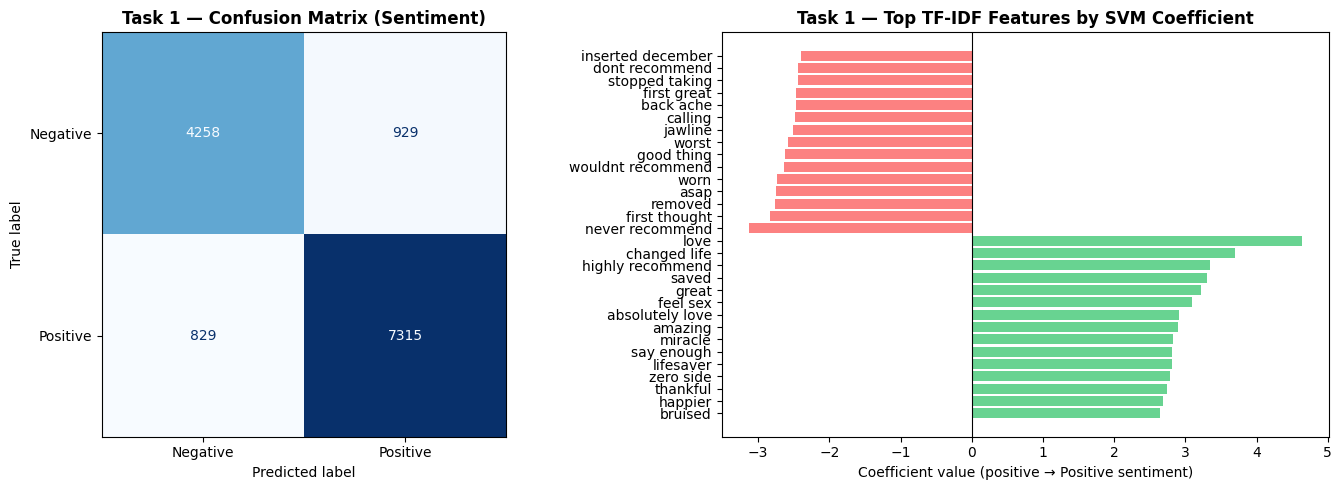

In [8]:
# Confusion matrix Task 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_s_test, y_pred_s)
ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Task 1 — Confusion Matrix (Sentiment)', fontweight='bold')

# Top positive and negative words by SVM coefficient
coefs      = svm.coef_[0]
top_pos    = np.argsort(coefs)[-15:][::-1]
top_neg    = np.argsort(coefs)[:15]
words_pos  = [feature_names[i] for i in top_pos]
words_neg  = [feature_names[i] for i in top_neg]
vals_pos   = [coefs[i] for i in top_pos]
vals_neg   = [coefs[i] for i in top_neg]

y_pos = range(len(words_pos))
axes[1].barh([w for w in reversed(words_pos)], [v for v in reversed(vals_pos)], color='#68d391')
axes[1].barh([w for w in words_neg], [v for v in vals_neg], color='#fc8181')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Task 1 — Top TF-IDF Features by SVM Coefficient', fontweight='bold')
axes[1].set_xlabel('Coefficient value (positive → Positive sentiment)')

plt.tight_layout()
plt.savefig('task1_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Task 2 — Theme Classification (Logistic Regression)

**Model:** Logistic Regression Multinomial — classifies feedback into one of 4 themes using the same TF-IDF matrix.

**Target:** Theme (Anxiety, Birth Control, Depression, Pain)

In [9]:
lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
lr.fit(X_train, y_t_train)
y_pred_t = lr.predict(X_test)

acc_t  = accuracy_score(y_t_test, y_pred_t)
f1_m_t = f1_score(y_t_test, y_pred_t, average='macro')
f1_w_t = f1_score(y_t_test, y_pred_t, average='weighted')

print('=' * 50)
print('TASK 2 — Theme Classification (LogReg Multinomial)')
print('=' * 50)
print(f'Accuracy   : {acc_t:.4f}')
print(f'F1 Macro   : {f1_m_t:.4f}')
print(f'F1 Weighted: {f1_w_t:.4f}')
print()
print(classification_report(y_t_test, y_pred_t, target_names=sorted(set(y_t_test))))

TASK 2 — Theme Classification (LogReg Multinomial)
Accuracy   : 0.9444
F1 Macro   : 0.9071
F1 Weighted: 0.9437

               precision    recall  f1-score   support

      Anxiety       0.87      0.76      0.81      1622
Birth Control       0.99      1.00      0.99      7678
   Depression       0.85      0.91      0.88      2426
         Pain       0.95      0.94      0.95      1605

     accuracy                           0.94     13331
    macro avg       0.92      0.90      0.91     13331
 weighted avg       0.94      0.94      0.94     13331



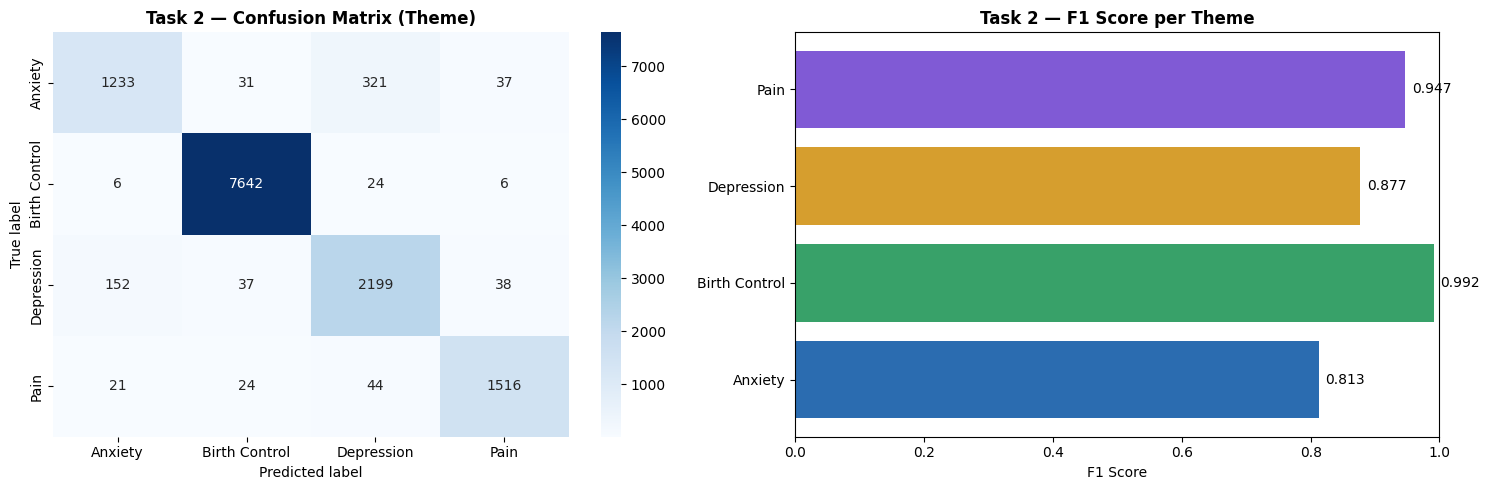

In [10]:
# Confusion matrix Task 2
theme_labels = sorted(set(y_t_test))
cm2 = confusion_matrix(y_t_test, y_pred_t, labels=theme_labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(
    cm2, annot=True, fmt='d', cmap='Blues',
    xticklabels=theme_labels, yticklabels=theme_labels,
    ax=axes[0]
)
axes[0].set_title('Task 2 — Confusion Matrix (Theme)', fontweight='bold')
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')

# Per-class F1 scores
f1_per_class = f1_score(y_t_test, y_pred_t, average=None, labels=theme_labels)
axes[1].barh(theme_labels, f1_per_class, color=['#2b6cb0', '#38a169', '#d69e2e', '#805ad5'])
axes[1].set_xlim(0, 1)
axes[1].set_title('Task 2 — F1 Score per Theme', fontweight='bold')
axes[1].set_xlabel('F1 Score')
for i, v in enumerate(f1_per_class):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('task2_theme.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Task 3 — NMF Topic Modeling

**Model:** Non-negative Matrix Factorization (NMF) — unsupervised, no labels used.

**Math:** $V \approx W \times H$ where:
- $V$ = TF-IDF matrix (documents × terms)
- $W$ = document-topic matrix (documents × topics)
- $H$ = topic-term matrix (topics × terms)

NMF finds latent topics **not** explicitly in the dataset.

In [11]:
nmf = NMF(n_components=4, max_iter=200, random_state=42)
W   = nmf.fit_transform(X_train)
H   = nmf.components_

recon_error = nmf.reconstruction_err_
print(f'Reconstruction error     : {recon_error:.4f}')
print(f'Document-topic matrix W  : {W.shape}  (documents × topics)')
print(f'Topic-term matrix H      : {H.shape}  (topics × terms)')
print()

topics = {}
for i, topic in enumerate(H):
    top_words = [feature_names[j] for j in topic.argsort()[-10:][::-1]]
    topics[f'Topic {i+1}'] = top_words
    print(f'Topic {i+1}: {", ".join(top_words)}')

Reconstruction error     : 226.0206
Document-topic matrix W  : (53323, 4)  (documents × topics)
Topic-term matrix H      : (4, 10000)  (topics × terms)

Topic 1: period, month, birth, pill, control, birth control, ive, weight, first, got
Topic 2: anxiety, depression, feel, life, taking, day, take, like, attack, medication
Topic 3: pain, back, work, take, relief, hour, back pain, day, medicine, doctor
Topic 4: effect, side effect, side, experienced, nausea, negative, bad side, great, far, negative side


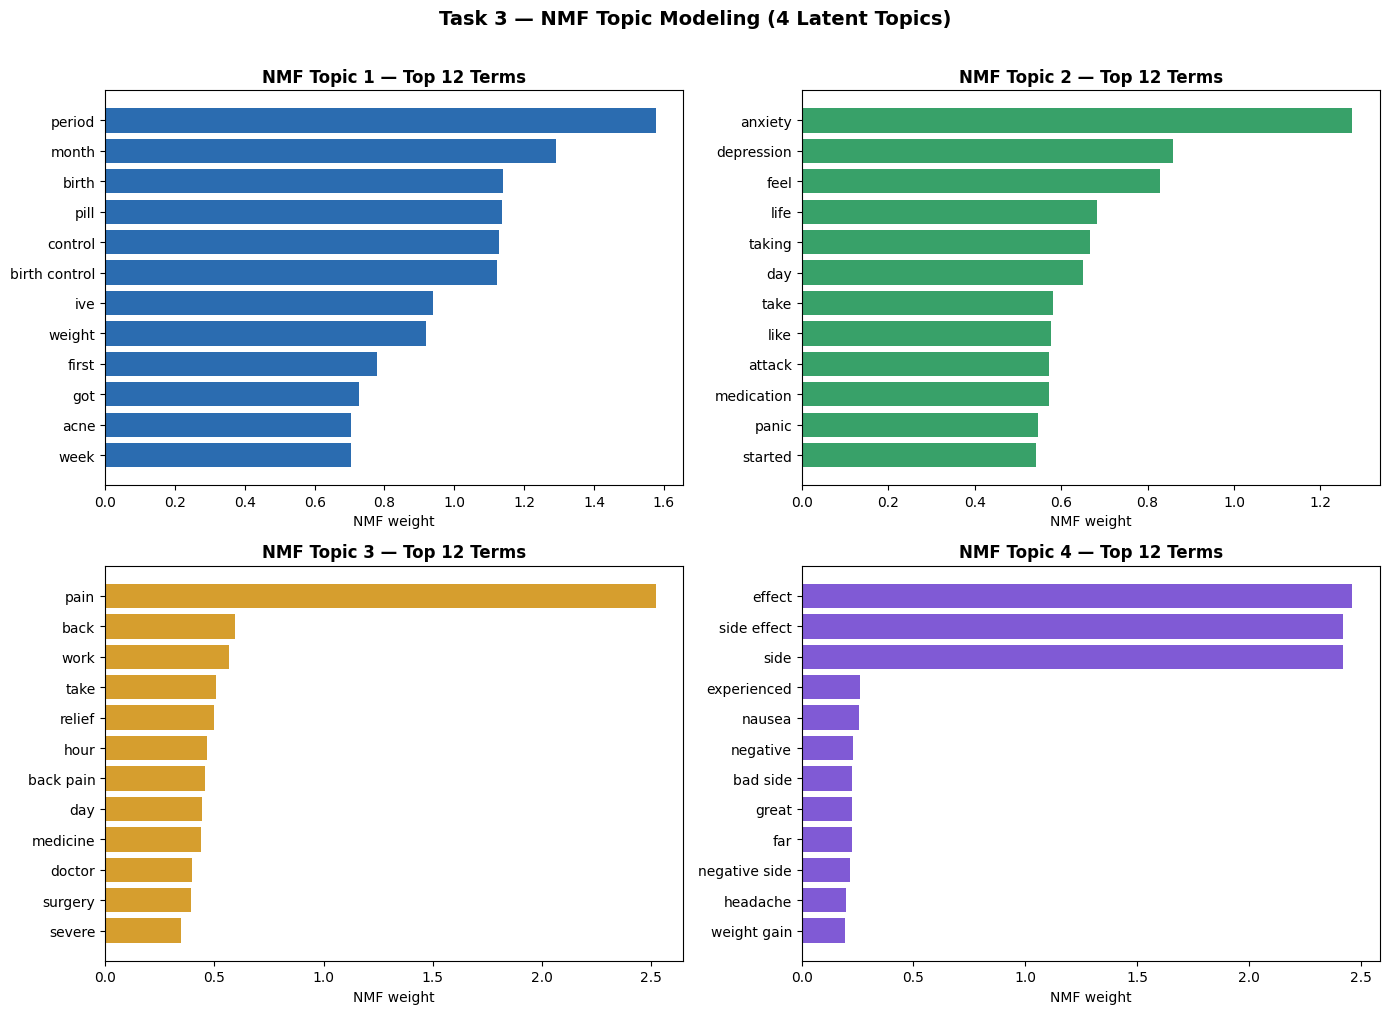

In [12]:
# Visualize NMF topics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors_nmf = ['#2b6cb0', '#38a169', '#d69e2e', '#805ad5']

for i, topic in enumerate(H):
    top_idx   = topic.argsort()[-12:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    top_vals  = [topic[j] for j in top_idx]
    axes[i].barh(list(reversed(top_words)), list(reversed(top_vals)), color=colors_nmf[i])
    axes[i].set_title(f'NMF Topic {i+1} — Top 12 Terms', fontweight='bold')
    axes[i].set_xlabel('NMF weight')

plt.suptitle('Task 3 — NMF Topic Modeling (4 Latent Topics)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task3_nmf_topics.png', dpi=150, bbox_inches='tight')
plt.show()

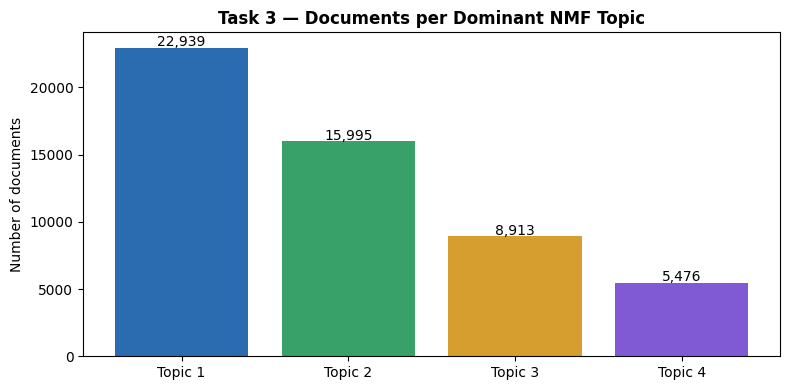

In [13]:
# Document-topic distribution — shows each doc's dominant topic
dominant_topics = W.argmax(axis=1)
topic_counts    = np.bincount(dominant_topics)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f'Topic {i+1}' for i in range(4)], topic_counts, color=colors_nmf)
ax.set_title('Task 3 — Documents per Dominant NMF Topic', fontweight='bold')
ax.set_ylabel('Number of documents')
for i, v in enumerate(topic_counts):
    ax.text(i, v + 100, f'{v:,}', ha='center')
plt.tight_layout()
plt.savefig('task3_topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary — All Metrics

In [14]:
print('=' * 60)
print('SUMMARY — ALL TASKS')
print('=' * 60)

print('\nTASK 1 — Sentiment Classification (LinearSVC + TF-IDF)')
print(f'  Dataset        : {len(df):,} patient drug reviews')
print(f'  Train / Test   : {len(X_train_text):,} / {len(X_test_text):,}')
print(f'  TF-IDF vocab   : {X_train.shape[1]:,} features')
print(f'  Accuracy       : {acc_s:.4f}')
print(f'  F1 Macro       : {f1_m_s:.4f}')
print(f'  AUC            : {auc:.4f}')
print(f'  Recall (neg)   : {rec_neg:.4f}  <- primary metric')

print('\nTASK 2 — Theme Classification (LogReg Multinomial + TF-IDF)')
print(f'  Classes        : Anxiety, Birth Control, Depression, Pain')
print(f'  Same TF-IDF    : yes (no refit, no leakage)')
print(f'  Accuracy       : {acc_t:.4f}')
print(f'  F1 Macro       : {f1_m_t:.4f}')
print(f'  F1 Weighted    : {f1_w_t:.4f}')

print('\nTASK 3 — NMF Topic Modeling (unsupervised + TF-IDF)')
print(f'  n_components   : 4 latent topics')
print(f'  No labels used : purely unsupervised')
print(f'  Recon. error   : {recon_error:.4f}')
print(f'  Topics found   :')
for name, words in topics.items():
    print(f'    {name}: {chr(44)+" ".join(words[:6])}')

print('\nPIPELINE: Raw text → HTML unescape → Lowercase → Remove punctuation')
print('          → Stopword removal → Lemmatization → TF-IDF (10k features, bigrams)')
print('          → Task 1: LinearSVC | Task 2: LogReg | Task 3: NMF')
print('=' * 60)

SUMMARY — ALL TASKS

TASK 1 — Sentiment Classification (LinearSVC + TF-IDF)
  Dataset        : 66,654 patient drug reviews
  Train / Test   : 53,323 / 13,331
  TF-IDF vocab   : 10,000 features
  Accuracy       : 0.8681
  F1 Macro       : 0.8608
  AUC            : 0.9327
  Recall (neg)   : 0.8209  <- primary metric

TASK 2 — Theme Classification (LogReg Multinomial + TF-IDF)
  Classes        : Anxiety, Birth Control, Depression, Pain
  Same TF-IDF    : yes (no refit, no leakage)
  Accuracy       : 0.9444
  F1 Macro       : 0.9071
  F1 Weighted    : 0.9437

TASK 3 — NMF Topic Modeling (unsupervised + TF-IDF)
  n_components   : 4 latent topics
  No labels used : purely unsupervised
  Recon. error   : 226.0206
  Topics found   :
    Topic 1: ,period month birth pill control birth control
    Topic 2: ,anxiety depression feel life taking day
    Topic 3: ,pain back work take relief hour
    Topic 4: ,effect side effect side experienced nausea negative

PIPELINE: Raw text → HTML unescape → L

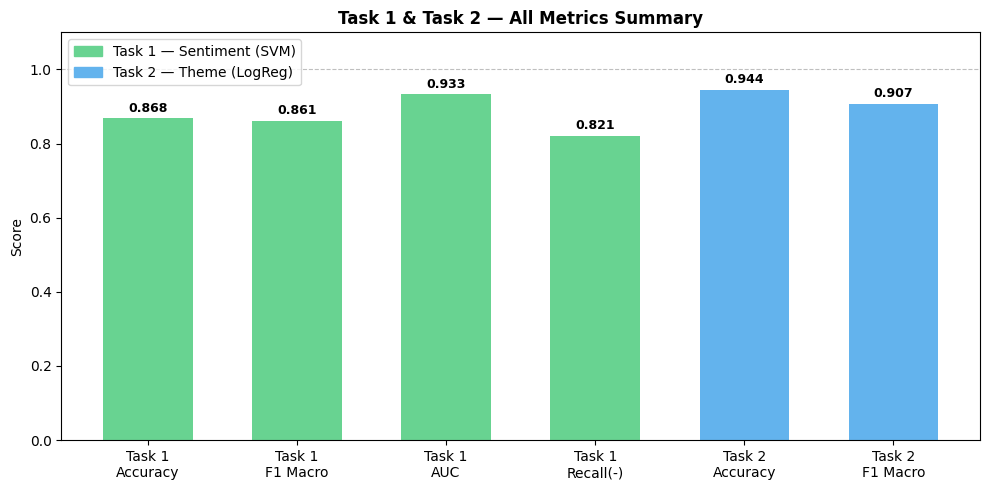

In [15]:
# Final comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))

metrics = {
    'Task 1\nAccuracy': acc_s,
    'Task 1\nF1 Macro': f1_m_s,
    'Task 1\nAUC':      auc,
    'Task 1\nRecall(-)': rec_neg,
    'Task 2\nAccuracy': acc_t,
    'Task 2\nF1 Macro': f1_m_t,
}
bar_colors = ['#68d391']*4 + ['#63b3ed']*2
bars = ax.bar(metrics.keys(), metrics.values(), color=bar_colors, width=0.6)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Task 1 & Task 2 — All Metrics Summary', fontweight='bold')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend = [Patch(color='#68d391', label='Task 1 — Sentiment (SVM)'),
          Patch(color='#63b3ed', label='Task 2 — Theme (LogReg)')]
ax.legend(handles=legend)
plt.tight_layout()
plt.savefig('all_metrics_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Verify Against Saved Models
Confirms that the saved `.pkl` models produce identical predictions.

In [16]:
saved_svm        = joblib.load('../models/sentiment_model.pkl')
saved_vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')
saved_theme      = joblib.load('../models/theme_model.pkl')

# Test on 3 real examples
test_texts = [
    "This medication completely changed my life for the better.",
    "The side effects were unbearable and I had to stop immediately.",
    "I feel so much less anxious since starting this treatment.",
]

print('Verification — saved model predictions:')
print('-' * 55)
for text in test_texts:
    cleaned = clean_text(text)
    X_vec   = saved_vectorizer.transform([cleaned])
    sent    = 'Positive' if saved_svm.predict(X_vec)[0] == 1 else 'Negative'
    theme   = saved_theme.predict(X_vec)[0]
    conf    = max(saved_theme.predict_proba(X_vec)[0])
    print(f'Text     : {text[:60]}')
    print(f'Sentiment: {sent} | Theme: {theme} ({conf*100:.0f}% confidence)')
    print()

print('Saved models verified successfully.')

Verification — saved model predictions:
-------------------------------------------------------
Text     : This medication completely changed my life for the better.
Sentiment: Positive | Theme: Anxiety (46% confidence)

Text     : The side effects were unbearable and I had to stop immediate
Sentiment: Negative | Theme: Birth Control (56% confidence)

Text     : I feel so much less anxious since starting this treatment.
Sentiment: Positive | Theme: Depression (46% confidence)

Saved models verified successfully.
